# Demographics Table

In this notebook, I built the demographics table as part of the ongoing manuscript.

Co-authors suggested:

- Age categories 
- Gravidity 
- Parity 
- Number of ANC visits
- GA at time of screening
- BMI (height/weight)

Delivery: 
- Place of delivery 
- Term/Preterm
- BW of newborn
- GA >37 / 32-37 /28-32/24-28 
- Given steroids (if <37/40)
- Complications: PPH/APH, Hypertension, infection, PPROM, etx.
- Treatment: Abx, oxytocin, dexamethasone, MagSulfate, blood transfucion.

- Delivery by: (midwife/nurse/dr) 

- Neonatal parameters 
- Neonatal mortality (<24hrs; 1-6 days; 7-27 days)
- Causes of death

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/dr.csv")

In [15]:
df.columns

Index(['Miscarriage', 'Outcome Death', 'Early Neonatal Death',
       'Late Neonatal Death', 'Pre-term Delivery', 'Gestation',
       'Expected Due Date', 'Last Menstrual Period',
       'Method of Determining Gestation', 'Maternal Age', 'School Level',
       'Years of Education', 'Parity', 'Maternal Height', 'Maternal Weight',
       'Antenatal Visits', 'Delivery By', 'Delivery Place',
       'Type of Delivery Place', 'Mode of Delivery', 'Baby Sex',
       'Multiple Birth', 'Birthweight', 'Birthweight Measure',
       'Neonatal Antibiotics', 'CPAP', 'Oxygen', 'Dexamethasone',
       'Kangaroo Mother Care', 'Cord care Chlorhexidine',
       'Bag and Mask Resuscitation'],
      dtype='object')

In [16]:
N = df.shape[0]

print("Total records", df.shape[0])

Total records 10596


In [17]:
import numpy as np
ages = df["Maternal Age"]


# Define bins and labels
bins   = [ -np.inf, 20, 25, 35, np.inf ]
labels = [   '<20',   '20-24',  '25-34',  '≥35' ]

# Categorize and count
categories = pd.cut(ages, bins=bins, labels=labels)
counts = categories.value_counts().sort_index()

# Create DataFrame with counts and percentages
pd.DataFrame({
    'Count': counts,
    'Percentage': (counts / N * 100).round(2)
})



,Count,Percentage
Maternal Age,,
<20,2313,21.83
20-24,3605,34.02
25-34,3895,36.76
≥35,757,7.14


In [18]:
df = df.drop(columns="Maternal Age")

In [19]:
heights = df["Maternal Height"]

# Define bins and labels
bins = [-float('inf'), 140, 159, 179, float('inf')]
labels = ['<1.40m', '1.40-1.59m', '1.60-1.79m', '≥1.80m']

# Categorize and count
categories = pd.cut(heights, bins=bins, labels=labels)
counts = categories.value_counts().sort_index()

# Create DataFrame with counts and percentages
pd.DataFrame({
    'Count': counts,
    'Percentage': (counts / N * 100).round(2)
})

,Count,Percentage
Maternal Height,,
<1.40m,50,0.47
1.40-1.59m,5657,53.39
1.60-1.79m,3652,34.47
≥1.80m,23,0.22


In [20]:
weights = df["Maternal Weight"]

# Define bins and labels
bins = [-float('inf'), 49.99, 59.99, 69.99, 79.99, 89.99, float('inf')]
labels = ['<50', '50-59', '60-69', '70-79', '80-89', '≥90']

# Categorize and count
categories = pd.cut(weights, bins=bins, labels=labels)
counts = categories.value_counts().sort_index()

# Create DataFrame with counts and percentages
pd.DataFrame({
    'Count': counts,
    'Percentage': (counts / N * 100).round(2)
})

,Count,Percentage
Maternal Weight,,
<50,514,4.85
50-59,3279,30.95
60-69,3744,35.33
70-79,1693,15.98
80-89,649,6.12
≥90,316,2.98


In [23]:
bmi = weights / (heights / 100) ** 2

bins = [-float('inf'), 18.49, 24.99, 29.99, 34.99, float('inf')]
labels = ['<18.5', '18.5-24.9', '25-29.9', '30-34.9', '≥35']

# Categorize and count
categories = pd.cut(bmi, bins=bins, labels=labels)
counts = categories.value_counts().sort_index()
# Create DataFrame with counts and percentages
pd.DataFrame({
    'Count': counts,
    'Percentage': (counts / N * 100).round(2)
})

,Count,Percentage
<18.5,91,0.86
18.5-24.9,4622,43.62
25-29.9,3173,29.95
30-34.9,944,8.91
≥35,312,2.94


(array([3.777e+03, 5.201e+03, 1.500e+02, 5.000e+00, 6.000e+00, 2.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([ 11.36334941,  24.11329707,  36.86324474,  49.6131924 ,
         62.36314006,  75.11308773,  87.86303539, 100.61298306,
        113.36293072, 126.11287838, 138.86282605]),
 <BarContainer object of 10 artists>)

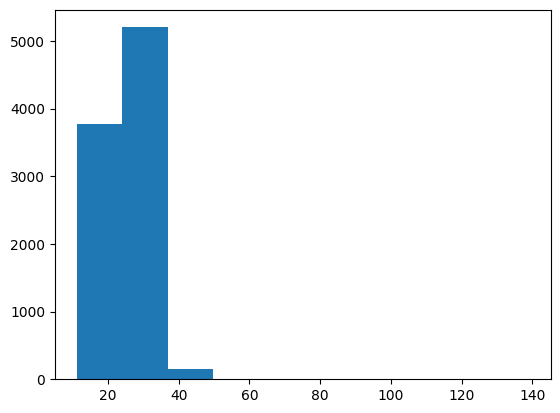

In [22]:
plt.hist(bmi)

In [24]:
df = df.drop(columns = "Maternal Height")
df = df.drop(columns="Maternal Weight")

In [140]:
df.columns

Index(['Miscarriage', 'Outcome Death', 'Early Neonatal Death',
       'Late Neonatal Death', 'Pre-term Delivery', 'Gestation',
       'Expected Due Date', 'Last Menstrual Period',
       'Method of Determining Gestation', 'School Level', 'Years of Education',
       'Parity', 'Antenatal Visits', 'Delivery By', 'Delivery Place',
       'Type of Delivery Place', 'Mode of Delivery', 'Baby Sex',
       'Multiple Birth', 'Birthweight', 'Birthweight Measure',
       'Neonatal Antibiotics', 'CPAP', 'Oxygen', 'Dexamethasone',
       'Kangaroo Mother Care', 'Cord care Chlorhexidine',
       'Bag and Mask Resuscitation'],
      dtype='object')

In [25]:
school_series = df["School Level"]

counts = school_series.value_counts(dropna=False).sort_index()

# Replace NaN label for display
counts.index = counts.index.fillna('Missing')

# Create DataFrame with count and percentage
pd.DataFrame({
    'Count': counts,
    'Percentage': (counts / N * 100).round(2)
})


,Count,Percentage
School Level,,
1=No formal education-Illiterate,300,2.83
2=No formal education-Literate,72,0.68
3=School,9905,93.48
4=College/University,314,2.96
Missing,5,0.05


In [26]:
df = df.drop(columns="School Level")

In [27]:
df = df.drop(columns="Years of Education")

In [28]:
parity_series = df["Parity"]

bins = [-0.1, 0.5, 1.5, 2.5, 3.5, float('inf')]
labels = ['0', '1', '2', '3', '≥4']

# Categorize and count
categories = pd.cut(parity_series, bins=bins, labels=labels)
counts = categories.value_counts().sort_index()

# Create DataFrame with count and percentage
pd.DataFrame({
    'Count': counts,
    'Percentage': (counts / N * 100).round(2)
})

,Count,Percentage
Parity,,
0,3167,29.89
1,2723,25.70
2,2053,19.38
3,1393,13.15
≥4,1253,11.83


In [29]:
df = df.drop(columns="Parity")

In [30]:
df.columns

Index(['Miscarriage', 'Outcome Death', 'Early Neonatal Death',
       'Late Neonatal Death', 'Pre-term Delivery', 'Gestation',
       'Expected Due Date', 'Last Menstrual Period',
       'Method of Determining Gestation', 'Antenatal Visits', 'Delivery By',
       'Delivery Place', 'Type of Delivery Place', 'Mode of Delivery',
       'Baby Sex', 'Multiple Birth', 'Birthweight', 'Birthweight Measure',
       'Neonatal Antibiotics', 'CPAP', 'Oxygen', 'Dexamethasone',
       'Kangaroo Mother Care', 'Cord care Chlorhexidine',
       'Bag and Mask Resuscitation'],
      dtype='object')

In [ ]:
df = df.drop(columns="Last Menstrual Period")
df = df.drop(columns="Expected Due Date")

In [35]:
df.columns

Index(['Miscarriage', 'Outcome Death', 'Early Neonatal Death',
       'Late Neonatal Death', 'Pre-term Delivery', 'Gestation',
       'Method of Determining Gestation', 'Antenatal Visits', 'Delivery By',
       'Delivery Place', 'Type of Delivery Place', 'Mode of Delivery',
       'Baby Sex', 'Multiple Birth', 'Birthweight', 'Birthweight Measure',
       'Neonatal Antibiotics', 'CPAP', 'Oxygen', 'Dexamethasone',
       'Kangaroo Mother Care', 'Cord care Chlorhexidine',
       'Bag and Mask Resuscitation'],
      dtype='object')

In [38]:
visits_series = df["Antenatal Visits"]

bins = [-0.1, 1.5, 2.5, 3.5, float('inf')]
labels = ['1', '2', '3', '≥4']

# Categorize and count
categories = pd.cut(visits_series, bins=bins, labels=labels)
counts = categories.value_counts().sort_index()

# Create DataFrame with counts and percentages
pd.DataFrame({
    'Count': counts,
    'Percentage': (counts / N * 100).round(2)
})


,Count,Percentage
Antenatal Visits,,
1,498,4.70
2,2297,21.68
3,4046,38.18
≥4,3661,34.55


In [39]:
df = df.drop(columns="Antenatal Visits")

In [40]:
df.columns

Index(['Miscarriage', 'Outcome Death', 'Early Neonatal Death',
       'Late Neonatal Death', 'Pre-term Delivery', 'Gestation',
       'Method of Determining Gestation', 'Delivery By', 'Delivery Place',
       'Type of Delivery Place', 'Mode of Delivery', 'Baby Sex',
       'Multiple Birth', 'Birthweight', 'Birthweight Measure',
       'Neonatal Antibiotics', 'CPAP', 'Oxygen', 'Dexamethasone',
       'Kangaroo Mother Care', 'Cord care Chlorhexidine',
       'Bag and Mask Resuscitation'],
      dtype='object')

In [42]:
gestation_series = df["Gestation"]/7


bins = [-float('inf'), 36.99, float('inf')]
labels = ['<37', '≥37']

# Categorize and count
categories = pd.cut(gestation_series, bins=bins, labels=labels)
counts = categories.value_counts().sort_index()

# Create DataFrame with count and percentage
pd.DataFrame({
    'Count': counts,
    'Percentage': (counts / N * 100).round(2)
})

,Count,Percentage
Gestation,,
<37,3157,29.79
≥37,7439,70.21


In [43]:
df = df.drop(columns="Gestation")

In [44]:
df.columns

Index(['Miscarriage', 'Outcome Death', 'Early Neonatal Death',
       'Late Neonatal Death', 'Pre-term Delivery',
       'Method of Determining Gestation', 'Delivery By', 'Delivery Place',
       'Type of Delivery Place', 'Mode of Delivery', 'Baby Sex',
       'Multiple Birth', 'Birthweight', 'Birthweight Measure',
       'Neonatal Antibiotics', 'CPAP', 'Oxygen', 'Dexamethasone',
       'Kangaroo Mother Care', 'Cord care Chlorhexidine',
       'Bag and Mask Resuscitation'],
      dtype='object')

In [45]:
df["Pre-term Delivery"].value_counts()

Pre-term Delivery
Term       7713
Preterm    2883
Name: count, dtype: int64

In [46]:
2883/N*100

27.2083805209513

In [47]:
7713/N*100

72.79161947904869

In [48]:
df = df.drop(columns="Pre-term Delivery")

In [49]:
df.columns

Index(['Miscarriage', 'Outcome Death', 'Early Neonatal Death',
       'Late Neonatal Death', 'Method of Determining Gestation', 'Delivery By',
       'Delivery Place', 'Type of Delivery Place', 'Mode of Delivery',
       'Baby Sex', 'Multiple Birth', 'Birthweight', 'Birthweight Measure',
       'Neonatal Antibiotics', 'CPAP', 'Oxygen', 'Dexamethasone',
       'Kangaroo Mother Care', 'Cord care Chlorhexidine',
       'Bag and Mask Resuscitation'],
      dtype='object')

In [50]:
# Example list of delivery providers
delivery = [
    '3=Nurse/Nurse midwife',
    '5=Family (No health provider)',
    '1=Obstetrician',
    '3=Nurse/Nurse midwife',
    '4=Traditional birth attendant',
    '2=Non-OB Physician',
    '3=Nurse/Nurse midwife',
    '5=Family (No health provider)',
    '6= Self delivery',
    '7=Other (specify)',
    '8=Don\'t know'
    # ... add more as needed
]

delivery_series = df["Delivery By"]

# Define top 3 categories to keep
top_3 = [
    '3=Nurse/Nurse midwife',
    '5=Family (No health provider)',
    '1=Obstetrician'
]

# Map all others to "Other"
delivery_cleaned = delivery_series.apply(lambda x: x if x in top_3 else '5=Family (No health provider)')

# Count and sort
counts = delivery_cleaned.value_counts().sort_index()

# Create DataFrame with counts and percentages
pd.DataFrame({
    'Count': counts,
    'Percentage': (counts / N * 100).round(2)
})

,Count,Percentage
Delivery By,,
1=Obstetrician,243,2.29
3=Nurse/Nurse midwife,9852,92.98
5=Family (No health provider),501,4.73


In [161]:
df = df.drop(columns="Delivery By")

In [162]:
df = df.drop(columns = "Type of Delivery Place")

In [163]:
df["Delivery Place"].value_counts()/N*100

Hospital                73.622122
Clinic/Health Center    21.706304
Home                     4.388448
Other                    0.151000
Name: Delivery Place, dtype: float64

In [51]:
df = df.drop(columns = "Delivery Place")

In [165]:
df.columns

Index(['Miscarriage', 'Outcome Death', 'Early Neonatal Death',
       'Late Neonatal Death', 'Method of Determining Gestation',
       'Mode of Delivery', 'Baby Sex', 'Multiple Birth', 'Birthweight',
       'Birthweight Measure', 'Neonatal Antibiotics', 'CPAP', 'Oxygen',
       'Dexamethasone', 'Kangaroo Mother Care', 'Cord care Chlorhexidine',
       'Bag and Mask Resuscitation'],
      dtype='object')

In [52]:
birthweight_series = df["Birthweight"]

bins = [-float('inf'), 2499, float('inf')]
labels = ['<2500', '≥2500']

# Categorize and count
categories = pd.cut(birthweight_series, bins=bins, labels=labels)
counts = categories.value_counts().sort_index()

# Create DataFrame with count and percentage
pd.DataFrame({
    'Count': counts,
    'Percentage': (counts / N * 100).round(2)
})

,Count,Percentage
Birthweight,,
<2500,958,9.04
≥2500,9480,89.47


In [167]:
N = df.shape[0]

df["Baby Sex"].value_counts() / N

Female    0.500283
Male      0.494715
Name: Baby Sex, dtype: float64

In [169]:
df.columns

Index(['Miscarriage', 'Outcome Death', 'Early Neonatal Death',
       'Late Neonatal Death', 'Method of Determining Gestation',
       'Mode of Delivery', 'Baby Sex', 'Multiple Birth', 'Birthweight',
       'Birthweight Measure', 'Neonatal Antibiotics', 'CPAP', 'Oxygen',
       'Dexamethasone', 'Kangaroo Mother Care', 'Cord care Chlorhexidine',
       'Bag and Mask Resuscitation'],
      dtype='object')

In [172]:
df["Mode of Delivery"].value_counts()/N

Vaginal     0.974991
Cesarean    0.017365
Name: Mode of Delivery, dtype: float64

In [179]:
df["Miscarriage"].value_counts()/N*100

No miscarriage    99.707437
Miscarriage        0.292563
Name: Miscarriage, dtype: float64

In [180]:
df["Early Neonatal Death"].value_counts()/N*100

Alive    97.300868
Dead      1.057003
Name: Early Neonatal Death, dtype: float64

In [181]:
df["Late Neonatal Death"].value_counts()/N*100

Alive    96.923367
Dead      0.207626
Name: Late Neonatal Death, dtype: float64

In [182]:
df["Neonatal Antibiotics"].value_counts()

0.0    10369
2.0      171
1.0       25
Name: Neonatal Antibiotics, dtype: int64

In [184]:
df["CPAP"].value_counts()

0.0    10384
2.0      175
1.0       10
Name: CPAP, dtype: int64

In [186]:
df["Oxygen"].value_counts()

0.0    10342
2.0      175
1.0       56
Name: Oxygen, dtype: int64

In [187]:
175+56

231

In [188]:
df["Dexamethasone"].value_counts()

0.0    10441
2.0      112
1.0       20
Name: Dexamethasone, dtype: int64

In [189]:
df["Bag and Mask Resuscitation"].value_counts()

0.0    10190
2.0      252
1.0      135
Name: Bag and Mask Resuscitation, dtype: int64

In [190]:
252+135

387

In [191]:
df["Cord care Chlorhexidine"].value_counts()

1.0    6768
0.0    3672
2.0     135
Name: Cord care Chlorhexidine, dtype: int64

In [194]:
6768+135

6903

In [195]:
df["Kangaroo Mother Care"].value_counts()

0.0    9260
1.0    1171
2.0     125
Name: Kangaroo Mother Care, dtype: int64

In [53]:
10596-31-143-112-22

10288

In [55]:
10288/10596

0.9709324273310683

In [196]:
1171+125

1296

In [197]:
counts = [196, 185, 231, 132, 387, 6903, 1296]

# Total
N = 10596

# Create DataFrame
df_ = pd.DataFrame({
    'Count': counts
})

# Calculate percentage
df_['Percentage'] = (df_['Count'] / N * 100).round(2)

print(df_)

   Count  Percentage
0    196        1.85
1    185        1.75
2    231        2.18
3    132        1.25
4    387        3.65
5   6903       65.15
6   1296       12.23


In [199]:
df["Outcome Death"].value_counts()

Live birth                   10422
Miscarriage or Stillbirth      174
Name: Outcome Death, dtype: int64

In [201]:
df["Miscarriage"].value_counts()

No miscarriage    10565
Miscarriage          31
Name: Miscarriage, dtype: int64

In [202]:
174-31

143

In [203]:
143/N

0.013495658739146849